In [3]:
import numpy as np
import pandas as pd

subscription_months = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]).reshape(-1,1)
renewed = np.array([0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1])
df = pd.DataFrame({'Subscription Months': subscription_months.flatten(),'Renewed': renewed})
print(df)

    Subscription Months  Renewed
0                     1        0
1                     2        0
2                     3        0
3                     4        0
4                     5        0
5                     6        0
6                     7        0
7                     8        1
8                     9        1
9                    10        1
10                   11        1
11                   12        1
12                   13        1
13                   14        1
14                   15        1
15                   16        1
16                   17        1
17                   18        1
18                   19        1
19                   20        1


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
X_train, X_test, y_train, y_test = train_test_split(subscription_months,renewed,test_size=0.2,random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix
[[2 0]
 [0 2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [9]:
new_customer = np.array([[9]])
prediction = model.predict(new_customer)[0]
probability = model.predict_proba(new_customer)[0]

print("\nNew Customer")
print("Subscription Months:", new_customer[0][0])
print("Prediction:", "Will Renew" )



New Customer
Subscription Months: 9
Prediction: Will Renew


In [10]:
if prediction == 1:
    print("Probability of Renewing: {:.2f}%".format(probability[1]*100))
else:
    print("Probability of Not Renewing: {:.2f}%".format(probability[0]*100))


Probability of Renewing: 85.66%


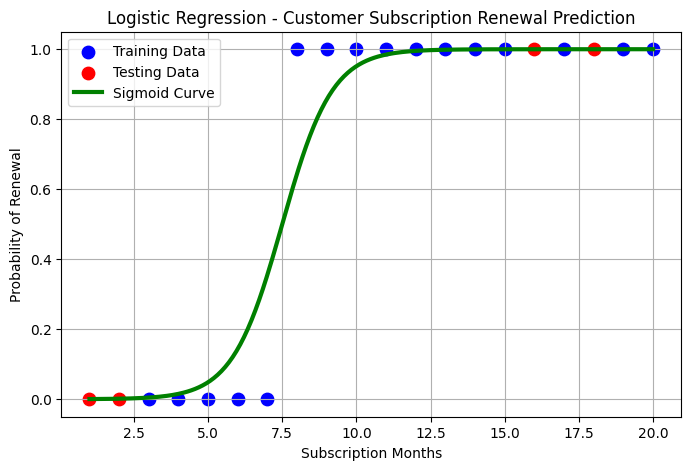

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color='blue', s=80, label='Training Data')
plt.scatter(X_test, y_test, color='red', s=80, label='Testing Data')

X_range = np.linspace(subscription_months.min(), subscription_months.max(), 300).reshape(-1,1)
y_curve = model.predict_proba(X_range)[:,1]

plt.plot(X_range, y_curve, color='green', linewidth=3, label='Sigmoid Curve')
plt.xlabel("Subscription Months")
plt.ylabel("Probability of Renewal")
plt.title("Logistic Regression - Customer Subscription Renewal Prediction")
plt.legend()
plt.grid(True)
plt.show()